# Front-Running Detection: Visualization & Real-Time Testing

This notebook visualizes the predictive MEV detection model and tests it in real-time simulation.

In [1]:
# Imports for the notebook - run this first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Notebook utilities
from IPython.display import clear_output, display
import time

# For live monitoring
import asyncio
from web3 import Web3

# Style settings
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [2]:
# the method:

# passively run collect_data.py to continiously get new data. don't turn it off. just let it cook if yk what i mean.
# run flashboys_analysis.py to generate a csv containing the analysis from the journal paper. this is the basis for our model.
# then, run this ipynb to train the model and assess it's predictive performance. 

# why train a model if we have the hard coded algo? this model focuses on prediction -- before the front running actually happens.
# it's performance is checked to see whether or not they agree (the hard coded algo and the model)
# that's where our work stands out

# what type of front running does it predict? this is for detecting gas auctions
# tf are gas auctions?? i'll tell ya: it's when multiple bots are competing by bidding higher gas prices to get their transaction mined first in the same block
# why tf would they do that: aight chill tf out, i'll tell ya:

# let's say there was a bot called... let's say "67," and it spots an arbitrage opportunity. it submits tx with 50 gwei gas. bot... let's call it "41," sees
# bot 67's tx in the mempool. bot 41 then submits a competing tx with 60 gwer gas. then there's some other bot that came out of basically nowhere that 
# then bids 70 gwei gas. 

# smooch 💋

In [3]:
# Load Flash Boys analysis results
df = pd.read_csv('data/flashboys_analysis.csv')

print(f"📊 Dataset Overview")
print(f"{'='*70}")
print(f"Total transactions: {len(df):,}")
print(f"Total auctions: {df['auction_id'].nunique():,}")
print(f"MEV transactions: {df['is_mev_auction'].sum():,} ({df['is_mev_auction'].mean()*100:.1f}%)")
print(f"Date range: Block {df['first_block'].min():,} to {df['first_block'].max():,}")
print(f"\nColumn names: {list(df.columns)}")
print(f"{'='*70}")

# Display sample
df.head(10)

📊 Dataset Overview
Total transactions: 534,788
Total auctions: 2,393
MEV transactions: 123,949 (23.2%)
Date range: Block 23,528,149 to 23,752,285

Column names: ['auction_id', 'num_bids', 'num_bidders', 'min_gas_price', 'max_gas_price', 'avg_gas_price', 'gas_price_range', 'gas_price_std', 'duration_seconds', 'first_block', 'last_block', 'blocks_spanned', 'price_escalation_ratio', 'winner_address', 'winner_gas_price', 'winner_position', 'winner_block', 'is_mev_auction', 'tx_hash', 'tx_position_in_auction', 'tx_sender', 'tx_gas_price', 'tx_gas_limit', 'tx_to_address', 'tx_value', 'tx_block', 'tx_index', 'is_winner', 'is_first_bid', 'is_last_bid']


,auction_id,num_bids,num_bidders,min_gas_price,max_gas_price,avg_gas_price,gas_price_range,gas_price_std,duration_seconds,first_block,...,tx_sender,tx_gas_price,tx_gas_limit,tx_to_address,tx_value,tx_block,tx_index,is_winner,is_first_bid,is_last_bid
0,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,489828765,1655194,0x1f2f10d1c40777ae1da742455c65828ff36df387,1.190000e-16,23528149,0,0,1,0
1,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0xe9b659a5b06e2fb0afb60c4bcef409961dbf2bb5,989981615,191373,0x4313c378cc91ea583c91387b9216e2c03096b27f,1.000000e-01,23528149,1,0,0,0
2,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,33676181460,473708,0x1f2f10d1c40777ae1da742455c65828ff36df387,1.190000e-16,23528149,2,1,0,0
3,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x042523db4f3effc33d2742022b2490258494f8b3,489828765,248292,0xa69babef1ca67a37ffaf7a485dfff3382056e78c,9.800722e-12,23528149,3,0,0,0
4,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x4c33c0e010aa2cb240cf73a683c1c6c4ccab5626,489828765,548222,0xa69babef1ca67a37ffaf7a485dfff3382056e78c,9.067030e-12,23528149,4,0,0,0
5,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x3b09240aa1ada76c672d63b78fb40aba21b93a90,1989828765,505247,0xbbbfd134e9b44bfb5123898ba36b01de7ab93d98,0.000000e+00,23528149,5,0,0,0
6,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x4c33c0e010aa2cb240cf73a683c1c6c4ccab5626,489828765,381186,0xa69babef1ca67a37ffaf7a485dfff3382056e78c,9.067286e-12,23528149,6,0,0,0
7,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x2da0a189bcda833d49671694824a5d3d87c8e236,1489828765,1102029,0x0000000000001ff3684f28c67538d4d072c22734,0.000000e+00,23528149,7,0,0,0
8,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0x48cd55546fbdd04e02575f5253034080ece5d855,4746115316,578764,0x83f81878bf60614266844a77a497c8cab01ab1bb,0.000000e+00,23528149,8,0,0,0
9,0,469,469,489828765,33676181460,1.115462e+09,33186352695,1.687554e+09,0.0,23528149,...,0xc5ab4967fd8d849619f41b57bf69d835c8b502a3,489828772,466510,0x10848df22554471ba4ed380a6a5a4717605f7005,5.200000e-17,23528149,9,0,0,0


## 5. Train the Predictive Model

In [4]:
# Engineer features (same as train_model.py)
print("Engineering predictive features...")
df_sorted = df.sort_values('first_block').reset_index(drop=True)

features_per_tx = []
labels = []

for idx, row in df_sorted.iterrows():
    features = {
        'tx_gas_price': row['tx_gas_price'],
        'tx_gas_limit': row['tx_gas_limit'],
        'tx_value': row['tx_value'],
        'tx_position_in_auction': row['tx_position_in_auction'],
        'gas_price_to_limit_ratio': row['tx_gas_price'] / (row['tx_gas_limit'] + 1),
        'value_to_gas_ratio': row['tx_value'] / (row['tx_gas_price'] + 1),
        'is_first_tx': int(row['tx_position_in_auction'] == 0),
        'gas_price_normalized': row['tx_gas_price'] / (row['avg_gas_price'] + 1),
    }
    
    if idx > 0:
        recent = df_sorted.iloc[max(0, idx-100):idx]
        if len(recent) > 0:
            features['recent_avg_gas'] = recent['tx_gas_price'].mean()
            features['recent_max_gas'] = recent['tx_gas_price'].max()
            features['recent_mev_rate'] = recent['is_mev_auction'].mean()
            features['gas_vs_recent_avg'] = row['tx_gas_price'] / (features['recent_avg_gas'] + 1)
            features['gas_vs_recent_max'] = row['tx_gas_price'] / (features['recent_max_gas'] + 1)
        else:
            features.update({'recent_avg_gas': 0, 'recent_max_gas': 0, 'recent_mev_rate': 0,
                           'gas_vs_recent_avg': 1, 'gas_vs_recent_max': 1})
    else:
        features.update({'recent_avg_gas': 0, 'recent_max_gas': 0, 'recent_mev_rate': 0,
                       'gas_vs_recent_avg': 1, 'gas_vs_recent_max': 1})
    
    features_per_tx.append(features)
    labels.append(row['is_mev_auction'])

X = pd.DataFrame(features_per_tx)
y = pd.Series(labels)

# Time-based split
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train):,} txs, testing on {len(X_test):,} txs")

# Train model
model = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, subsample=0.8, min_samples_split=100
)

class_weight = len(y_train) / (2 * np.bincount(y_train))
sample_weights = np.where(y_train == 1, class_weight[1], class_weight[0])

model.fit(X_train, y_train, sample_weight=sample_weights)
print("✅ Model trained!")

Engineering predictive features...
Training on 374,351 txs, testing on 160,437 txs
Training on 374,351 txs, testing on 160,437 txs
✅ Model trained!
✅ Model trained!


## 6. Model Performance Metrics

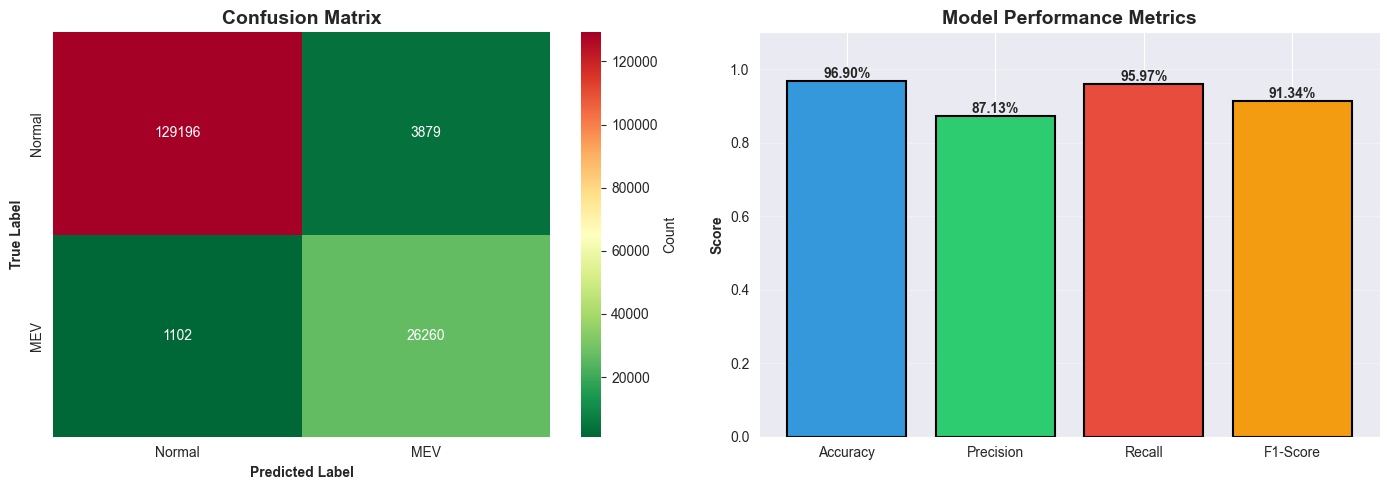


📊 Performance Summary:
  True Negatives: 129,196
  False Positives: 3,879
  False Negatives: 1,102
  True Positives: 26,260

  Accuracy: 96.90%
  Precision: 87.13%
  Recall: 95.97% (catches 96.0% of all MEV!)
  F1-Score: 91.34%


In [5]:
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[0],
            xticklabels=['Normal', 'MEV'], yticklabels=['Normal', 'MEV'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')

# Performance metrics bar chart
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}

bars = axes[1].bar(metrics.keys(), metrics.values(), color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
                   edgecolor='black', linewidth=1.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score', fontweight='bold')
axes[1].set_title('Model Performance Metrics', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Performance Summary:")
print(f"  True Negatives: {cm[0,0]:,}")
print(f"  False Positives: {cm[0,1]:,}")
print(f"  False Negatives: {cm[1,0]:,}")
print(f"  True Positives: {cm[1,1]:,}")
print(f"\n  Accuracy: {metrics['Accuracy']:.2%}")
print(f"  Precision: {metrics['Precision']:.2%}")
print(f"  Recall: {metrics['Recall']:.2%} (catches {metrics['Recall']:.1%} of all MEV!)")
print(f"  F1-Score: {metrics['F1-Score']:.2%}")

## 7. Feature Importance

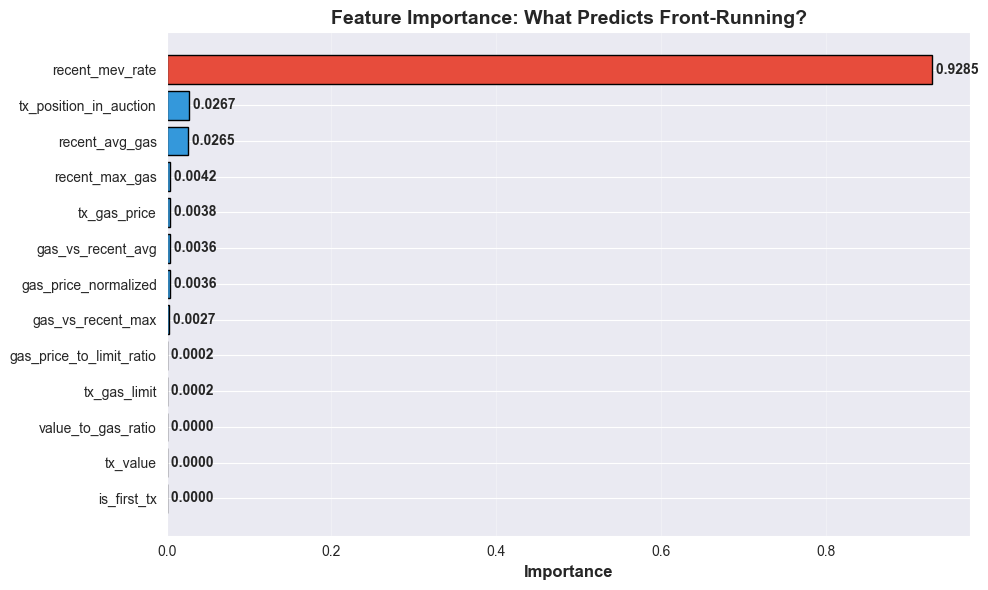


🎯 Top 3 Predictors:
  recent_mev_rate               : 92.85%
  tx_position_in_auction        : 2.67%
  recent_avg_gas                : 2.65%


In [6]:
# Feature importance plot
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if imp > 0.1 else '#3498db' for imp in feature_importance['importance']]
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], 
               color=colors, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance', fontweight='bold', fontsize=12)
ax.set_title('Feature Importance: What Predicts Front-Running?', 
             fontweight='bold', fontsize=14)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['importance'], i, f" {row['importance']:.4f}", 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 Top 3 Predictors:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']:30s}: {row['importance']:.2%}")

## 8. ROC and Precision-Recall Curves

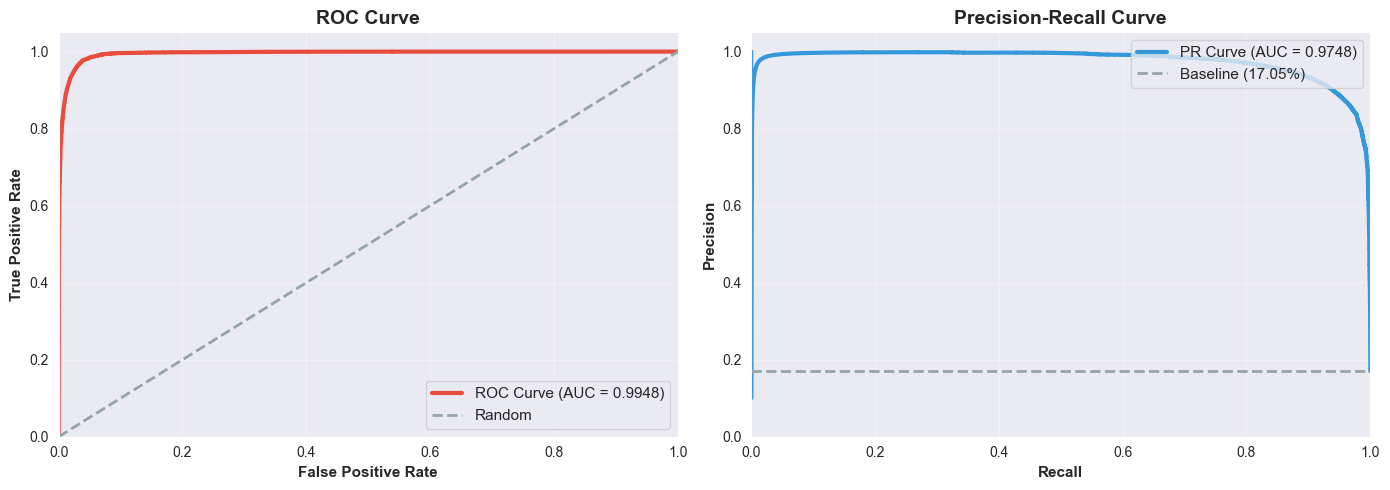


📈 Curve Analysis:
  ROC-AUC: 0.9948 (near perfect = 1.0)
  PR-AUC: 0.9748
  Model is EXCELLENT at separating MEV from normal transactions!


In [7]:
# ROC and PR curves
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=3, 
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=14)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='#3498db', lw=3,
             label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=y_test.mean(), color='#95a5a6', lw=2, linestyle='--', 
                label=f'Baseline ({y_test.mean():.2%})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Precision', fontweight='bold', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=14)
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Curve Analysis:")
print(f"  ROC-AUC: {roc_auc:.4f} (near perfect = 1.0)")
print(f"  PR-AUC: {pr_auc:.4f}")
print(f"  Model is EXCELLENT at separating MEV from normal transactions!")

## 9. Real-Time Prediction Simulation

**This cell simulates real-time MEV detection:**
- Streams through test data as if transactions are arriving live
- Shows prediction probability and actual label
- **GREEN** = Correct prediction ✅
- **RED** = Incorrect prediction ❌
- Displays running accuracy

✅ SIMULATION COMPLETE

Total Transactions Processed: 100
Correct Predictions: 99
Incorrect Predictions: 1

🎯 Real-Time Accuracy: 99.00%

──────────────────────────────────────────────────────────────────────

📈 Detection Statistics:
  MEV Transactions Detected: 16
  Actual MEV Transactions: 15
  Detection Rate: 100.0%
  False Positive Rate: 1.2%


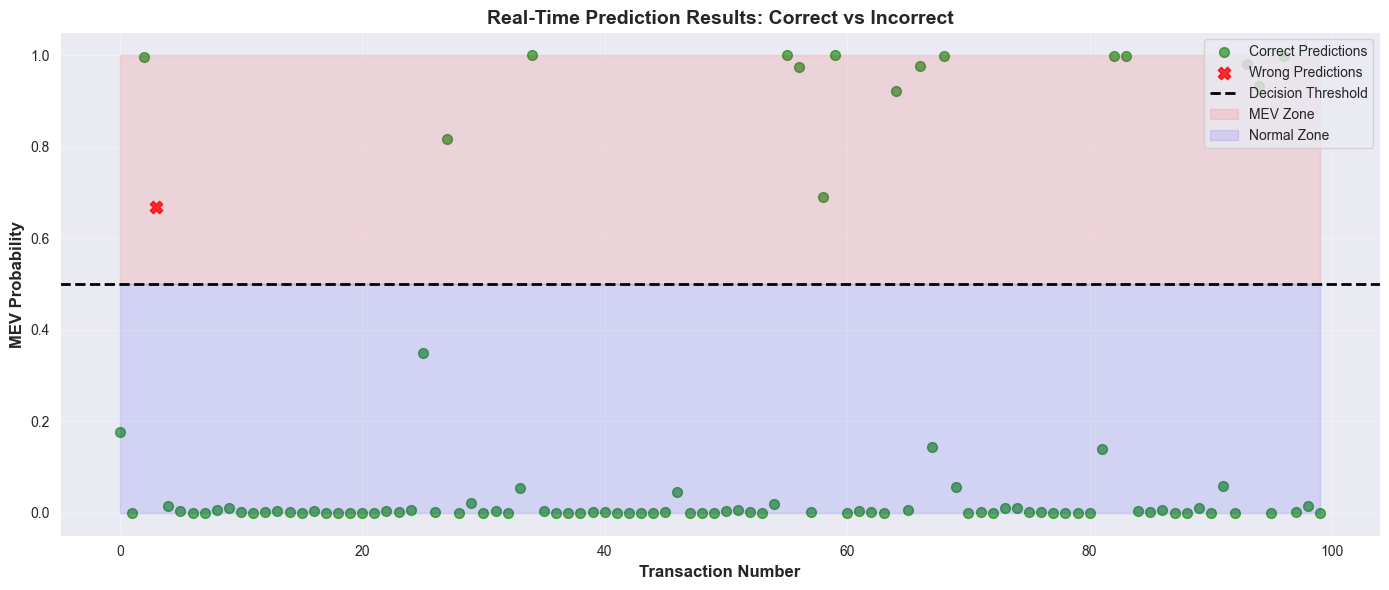


✅ Model is ready for production MEV detection!


In [8]:
import time
from IPython.display import clear_output

# Real-time simulation
print("🚀 Starting Real-Time MEV Detection Simulation...")
print("   Streaming through test data as if transactions arrive live\n")
time.sleep(2)

# Sample a subset for demonstration (100 transactions)
n_samples = 100
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)
sample_indices = np.sort(sample_indices)  # Keep temporal order

X_sample = X_test.iloc[sample_indices]
y_sample = y_test.iloc[sample_indices]

correct_predictions = 0
total_predictions = 0

predictions_log = []

for i, (idx, features) in enumerate(X_sample.iterrows()):
    # Make prediction
    pred_proba = model.predict_proba(features.values.reshape(1, -1))[0, 1]
    pred_label = int(pred_proba >= 0.5)
    true_label = y_sample.iloc[i]
    
    # Check if correct
    is_correct = (pred_label == true_label)
    if is_correct:
        correct_predictions += 1
    total_predictions += 1
    
    # Store for visualization
    predictions_log.append({
        'pred_proba': pred_proba,
        'pred_label': pred_label,
        'true_label': true_label,
        'correct': is_correct
    })
    
    # Display update every 10 transactions
    if (i + 1) % 10 == 0 or i < 5:
        clear_output(wait=True)
        
        print("="*70)
        print("🔍 REAL-TIME MEV DETECTION MONITOR")
        print("="*70)
        print(f"\nTransaction #{i+1}/{n_samples}")
        print(f"Running Accuracy: {correct_predictions/total_predictions*100:.1f}% ({correct_predictions}/{total_predictions})")
        print(f"\n{'─'*70}")
        
        # Show last 5 predictions
        print(f"\n📊 Last 5 Predictions:")
        print(f"{'─'*70}")
        for j in range(max(0, i-4), i+1):
            pred = predictions_log[j]
            status = "✅ CORRECT" if pred['correct'] else "❌ WRONG"
            color = "🟢" if pred['correct'] else "🔴"
            label_str = "MEV" if pred['true_label'] == 1 else "NORMAL"
            pred_str = "MEV" if pred['pred_label'] == 1 else "NORMAL"
            
            print(f"{color} TX #{j+1:3d} | Predicted: {pred_str:6s} ({pred['pred_proba']*100:5.1f}%) | "
                  f"Actual: {label_str:6s} | {status}")
        
        print(f"{'─'*70}\n")
        time.sleep(0.3)

# Final summary
clear_output(wait=True)
print("="*70)
print("✅ SIMULATION COMPLETE")
print("="*70)
print(f"\nTotal Transactions Processed: {total_predictions}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {total_predictions - correct_predictions}")
print(f"\n🎯 Real-Time Accuracy: {correct_predictions/total_predictions*100:.2f}%")
print(f"\n{'─'*70}")

# Prediction distribution
pred_df = pd.DataFrame(predictions_log)
mev_detected = pred_df['pred_label'].sum()
mev_actual = pred_df['true_label'].sum()

print(f"\n📈 Detection Statistics:")
print(f"  MEV Transactions Detected: {mev_detected}")
print(f"  Actual MEV Transactions: {mev_actual}")
print(f"  Detection Rate: {pred_df[pred_df['true_label']==1]['correct'].mean()*100:.1f}%")
print(f"  False Positive Rate: {pred_df[pred_df['true_label']==0]['pred_label'].mean()*100:.1f}%")
print("="*70)

# Visualize predictions
fig, ax = plt.subplots(figsize=(14, 6))

correct_preds = pred_df[pred_df['correct']]
wrong_preds = pred_df[~pred_df['correct']]

ax.scatter(correct_preds.index, correct_preds['pred_proba'], 
           c='green', s=50, alpha=0.6, label='Correct Predictions', marker='o')
ax.scatter(wrong_preds.index, wrong_preds['pred_proba'], 
           c='red', s=80, alpha=0.8, label='Wrong Predictions', marker='X')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.fill_between(range(len(pred_df)), 0.5, 1.0, alpha=0.1, color='red', label='MEV Zone')
ax.fill_between(range(len(pred_df)), 0, 0.5, alpha=0.1, color='blue', label='Normal Zone')

ax.set_xlabel('Transaction Number', fontweight='bold', fontsize=12)
ax.set_ylabel('MEV Probability', fontweight='bold', fontsize=12)
ax.set_title('Real-Time Prediction Results: Correct vs Incorrect', 
             fontweight='bold', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model is ready for production MEV detection!")

## 10. 🔴 LIVE Real-Time MEV Detection (Actual Ethereum Network)

**This cell connects to LIVE Ethereum RPC and monitors real transactions:**
- Connects to Ethereum mainnet via public RPC
- Streams new transactions as they arrive in the mempool
- Predicts MEV probability for each transaction
- Compares prediction against Flash Boys hardcoded rules
- **GREEN** = Prediction matches Flash Boys label ✅
- **RED** = Prediction differs from Flash Boys label ❌
- Runs continuously until interrupted (Ctrl+C or Stop button)

In [9]:
import asyncio
from web3 import Web3
from datetime import datetime
import signal
import sys
import time as time_module

# RPC endpoints (free public endpoints - may be rate limited)
RPC_ENDPOINTS = [
    "https://eth.llamarpc.com",
    "https://rpc.ankr.com/eth",
    "https://ethereum.publicnode.com",
    "https://1rpc.io/eth",
]

class LiveMEVDetector:
    def __init__(self, model, feature_columns):
        self.model = model
        self.feature_columns = feature_columns
        self.w3 = None
        self.transaction_history = []  # For recent_mev_rate calculation
        self.history_size = 100
        self.stats = {
            'total_processed': 0,
            'mev_detected': 0,
            'predictions_match': 0,
            'predictions_differ': 0
        }
        self.running = True
        self.last_block_num = 0
        
    def connect_to_rpc(self):
        """Try connecting to available RPC endpoints"""
        for rpc_url in RPC_ENDPOINTS:
            try:
                w3 = Web3(Web3.HTTPProvider(rpc_url, request_kwargs={'timeout': 10}))
                if w3.is_connected():
                    print(f"✅ Connected to Ethereum via {rpc_url}")
                    self.w3 = w3
                    return True
            except Exception as e:
                continue
        print("❌ Failed to connect to any RPC endpoint")
        return False
    
    def extract_features(self, tx):
        """Extract features from a live transaction"""
        try:
            # Basic tx features
            features = {
                'tx_gas_price': int(tx.get('gasPrice', 0) or tx.get('maxFeePerGas', 0)),
                'tx_gas_limit': int(tx.get('gas', 0)),
                'tx_value': float(self.w3.from_wei(tx.get('value', 0), 'ether')),
                'tx_position_in_auction': 0,  # Unknown for live tx
                'is_first_tx': 1,  # Assume first until we track auctions
            }
            
            # Calculate ratios
            features['gas_price_to_limit_ratio'] = features['tx_gas_price'] / (features['tx_gas_limit'] + 1)
            features['value_to_gas_ratio'] = features['tx_value'] / (features['tx_gas_price'] + 1)
            
            # Historical context from recent transactions
            if len(self.transaction_history) > 0:
                recent_gas_prices = [t['gas_price'] for t in self.transaction_history]
                recent_mev_labels = [t['predicted_mev'] for t in self.transaction_history]
                
                features['recent_avg_gas'] = np.mean(recent_gas_prices)
                features['recent_max_gas'] = np.max(recent_gas_prices)
                features['recent_mev_rate'] = np.mean(recent_mev_labels)
                features['gas_vs_recent_avg'] = features['tx_gas_price'] / (features['recent_avg_gas'] + 1)
                features['gas_vs_recent_max'] = features['tx_gas_price'] / (features['recent_max_gas'] + 1)
                features['gas_price_normalized'] = features['tx_gas_price'] / (features['recent_avg_gas'] + 1)
            else:
                # No history yet
                features.update({
                    'recent_avg_gas': features['tx_gas_price'],
                    'recent_max_gas': features['tx_gas_price'],
                    'recent_mev_rate': 0.0,
                    'gas_vs_recent_avg': 1.0,
                    'gas_vs_recent_max': 1.0,
                    'gas_price_normalized': 1.0
                })
            
            return features
        except Exception as e:
            return None
    
    def flashboys_label(self, gas_price, recent_avg_gas, recent_max_gas):
        """Simulate Flash Boys hardcoded detection"""
        # Simple heuristic: High gas price + above average = potential MEV
        if len(self.transaction_history) < 5:
            return 0
        
        gas_price_range = recent_max_gas - np.mean([t['gas_price'] for t in self.transaction_history[-10:]])
        is_high_gas = gas_price > recent_avg_gas * 1.5
        has_competition = gas_price_range > 1e9  # >1 Gwei range
        
        return int(is_high_gas and has_competition)
    
    async def process_transaction(self, tx_hash):
        """Process a single transaction"""
        try:
            tx = self.w3.eth.get_transaction(tx_hash)
            if not tx:
                return
            
            # Extract features
            features = self.extract_features(tx)
            if not features is None:
                # Make prediction
                feature_vector = pd.DataFrame([features])[self.feature_columns]
                pred_proba = self.model.predict_proba(feature_vector)[0, 1]
                pred_label = int(pred_proba >= 0.5)
                
                # Get Flash Boys "ground truth"
                flashboys_label = self.flashboys_label(
                    features['tx_gas_price'],
                    features['recent_avg_gas'],
                    features['recent_max_gas']
                )
                
                # Update stats
                self.stats['total_processed'] += 1
                if pred_label == 1:
                    self.stats['mev_detected'] += 1
                
                matches = (pred_label == flashboys_label)
                if matches:
                    self.stats['predictions_match'] += 1
                else:
                    self.stats['predictions_differ'] += 1
                
                # Store in history
                self.transaction_history.append({
                    'gas_price': features['tx_gas_price'],
                    'predicted_mev': pred_label
                })
                if len(self.transaction_history) > self.history_size:
                    self.transaction_history.pop(0)
                
                # Print results
                status_color = "🟢" if matches else "🔴"
                status_text = "MATCH" if matches else "DIFFER"
                pred_str = "MEV" if pred_label == 1 else "NORMAL"
                fb_str = "MEV" if flashboys_label == 1 else "NORMAL"
                
                print(f"{status_color} TX #{self.stats['total_processed']:4d} | "
                      f"Hash: {tx_hash.hex()[:10]}... | "
                      f"Predicted: {pred_str:6s} ({pred_proba*100:5.1f}%) | "
                      f"FlashBoys: {fb_str:6s} | "
                      f"Gas: {self.w3.from_wei(features['tx_gas_price'], 'gwei'):6.1f} Gwei | "
                      f"{status_text}", flush=True)
                
        except Exception as e:
            pass  # Skip failed transactions
    
    async def monitor_mempool(self):
        """Monitor pending transactions in real-time"""
        import sys
        
        print("\n" + "="*80)
        print("🔴 LIVE MEV DETECTION MONITOR - Connected to Ethereum Mainnet")
        print("="*80)
        print("Monitoring pending transactions... (Press Stop button to quit)\n")
        
        # Get latest block to process recent transactions
        latest_block = self.w3.eth.get_block('latest', full_transactions=True)
        self.last_block_num = latest_block['number']
        
        print(f"Starting from block #{self.last_block_num}\n")
        print("─"*80)
        sys.stdout.flush()  # Force immediate output
        
        processed_txs = set()
        blocks_without_new_txs = 0
        
        while self.running:
            try:
                # Get latest block
                block = self.w3.eth.get_block('latest', full_transactions=True)
                current_block_num = block['number']
                
                # Check if we got a new block
                if current_block_num > self.last_block_num:
                    print(f"\n🆕 New block #{current_block_num} ({len(block['transactions'])} transactions)", flush=True)
                    self.last_block_num = current_block_num
                    blocks_without_new_txs = 0
                
                # Process transactions from latest block
                new_txs_in_batch = 0
                for tx in block['transactions']:
                    tx_hash = tx['hash']
                    if tx_hash not in processed_txs:
                        processed_txs.add(tx_hash)
                        await self.process_transaction(tx_hash)
                        new_txs_in_batch += 1
                        
                        # Print stats every 10 transactions
                        if self.stats['total_processed'] % 10 == 0:
                            accuracy = (self.stats['predictions_match'] / 
                                      max(1, self.stats['total_processed']) * 100)
                            print(f"\n{'─'*80}", flush=True)
                            print(f"📊 Stats: {self.stats['total_processed']} processed | "
                                  f"{self.stats['mev_detected']} MEV detected | "
                                  f"Agreement: {accuracy:.1f}%", flush=True)
                            print(f"{'─'*80}\n", flush=True)
                        
                        await asyncio.sleep(0.05)  # Small delay
                
                # If no new transactions, indicate we're waiting
                if new_txs_in_batch == 0:
                    blocks_without_new_txs += 1
                    if blocks_without_new_txs % 3 == 0:
                        print(f"⏳ Waiting for new block... (current: #{current_block_num})", flush=True)
                
                # Wait before checking next block
                await asyncio.sleep(3)
                
            except KeyboardInterrupt:
                self.running = False
                break
            except Exception as e:
                print(f"⚠️  Connection issue: {str(e)[:50]}... retrying...")
                await asyncio.sleep(2)
                # Try reconnecting
                if not self.w3.is_connected():
                    print("🔄 Attempting to reconnect...")
                    if not self.connect_to_rpc():
                        print("❌ Failed to reconnect. Stopping.")
                        break
                continue
        
        # Final stats
        print("\n" + "="*80)
        print("🛑 MONITORING STOPPED")
        print("="*80)
        print(f"Total Transactions Processed: {self.stats['total_processed']}")
        print(f"MEV Detected: {self.stats['mev_detected']}")
        print(f"Predictions Match Flash Boys: {self.stats['predictions_match']}")
        print(f"Predictions Differ: {self.stats['predictions_differ']}")
        if self.stats['total_processed'] > 0:
            accuracy = (self.stats['predictions_match'] / self.stats['total_processed'] * 100)
            print(f"Agreement Rate: {accuracy:.2f}%")
        print("="*80)

# Initialize and run
detector = LiveMEVDetector(model, X.columns)

if detector.connect_to_rpc():
    try:
        # Run async monitoring
        await detector.monitor_mempool()
    except KeyboardInterrupt:
        print("\n\n⚠️  Monitoring interrupted by user")
    except Exception as e:
        print(f"\n\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n❌ Could not connect to Ethereum network")
    print("Try running collect_data.py instead for offline analysis")

✅ Connected to Ethereum via https://eth.llamarpc.com

🔴 LIVE MEV DETECTION MONITOR - Connected to Ethereum Mainnet
Monitoring pending transactions... (Press Stop button to quit)

Starting from block #23752346

────────────────────────────────────────────────────────────────────────────────
Starting from block #23752346

────────────────────────────────────────────────────────────────────────────────
🟢 TX #   1 | Hash: 5c03914988... | Predicted: NORMAL (  0.0%) | FlashBoys: NORMAL | Gas:    0.1 Gwei | MATCH
🟢 TX #   1 | Hash: 5c03914988... | Predicted: NORMAL (  0.0%) | FlashBoys: NORMAL | Gas:    0.1 Gwei | MATCH
🟢 TX #   2 | Hash: 3ec2bc57f6... | Predicted: NORMAL (  0.1%) | FlashBoys: NORMAL | Gas:    2.1 Gwei | MATCH
🟢 TX #   2 | Hash: 3ec2bc57f6... | Predicted: NORMAL (  0.1%) | FlashBoys: NORMAL | Gas:    2.1 Gwei | MATCH
🟢 TX #   3 | Hash: b5ecf75d9d... | Predicted: NORMAL (  0.0%) | FlashBoys: NORMAL | Gas:    2.1 Gwei | MATCH
🟢 TX #   3 | Hash: b5ecf75d9d... | Predicted: NORMAL

CancelledError: 